# 🧠 EEG Brain Speller — Complete BCI Pipeline
**P300 Speller | Signal Processing | Machine Learning | Deep Learning**

---

## 📋 Table of Contents
1. [Environment Setup & Installation](#setup)
2. [Imports & Configuration](#imports)
3. [Dataset Download (MOABB)](#dataset)
4. [Raw EEG Exploration & Visualization](#explore)
5. [Preprocessing Pipeline](#preprocess)
   - Bandpass Filter
   - Notch Filter (50 Hz)
   - Re-referencing
   - Bad Channel Interpolation
   - ICA Artifact Removal
6. [Epoching & Baseline Correction](#epoching)
7. [ERP Visualization (P300 Component)](#erp)
8. [Feature Extraction](#features)
   - Downsampled Waveform
   - Xdawn Spatial Filtering
   - Covariance Matrices (Riemannian)
9. [Baseline Classifier — LDA](#lda)
10. [Strong Baseline — SVM](#svm)
11. [Deep Learning — EEGNet (PyTorch)](#eegnet)
12. [Ensemble / Score Averaging](#ensemble)
13. [Evaluation: ITR, Confusion Matrix, All Metrics](#evaluation)
14. [Results Summary & Comparison Table](#results)

---
> **Note:** Enable GPU in Colab: `Runtime → Change runtime type → T4 GPU`


## 1. Environment Setup & Installation <a name='setup'></a>

In [40]:
# ─────────────────────────────────────────────────────────
# CELL 1 — Install all required packages
# Run this cell FIRST. It takes ~3-5 minutes.
# ─────────────────────────────────────────────────────────
!pip install -q mne>=1.6.0 moabb>=0.5.0 scikit-learn>=1.3.0 matplotlib seaborn pandas scipy
!pip install -q braindecode pyriemann autoreject
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
print('✅ All packages installed successfully!')

✅ All packages installed successfully!


In [41]:
%matplotlib inline

## 2. Imports & Configuration <a name='imports'></a>

In [42]:
# ─────────────────────────────────────────────────────────
# CELL 2 — All imports
# ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Colab-safe backend
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# MNE
import mne
mne.set_log_level('WARNING')

# MOABB
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300

# Sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# MNE preprocessing tools
from mne.preprocessing import ICA
from mne.decoding import Vectorizer, Scaler

# Xdawn
from mne.decoding import UnsupervisedSpatialFilter
try:
    from pyriemann.estimation import ERPCovariances, Shrinkage
    from pyriemann.classification import MDM
    from pyriemann.tangentspace import TangentSpace
    PYRIEMANN_AVAILABLE = True
    print('✅ pyriemann available')
except ImportError:
    PYRIEMANN_AVAILABLE = False
    print('⚠️  pyriemann not available — Riemannian features will be skipped')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')
print(f'✅ MNE version: {mne.__version__}')
print('✅ All imports successful!')

✅ pyriemann available
✅ Using device: cuda
✅ MNE version: 1.12.0
✅ All imports successful!


## 3. Dataset Download (MOABB) <a name='dataset'></a>

We use **BNCI2014-009** — a standard P300 speller dataset with 10 subjects recorded with 16 EEG channels.

In [43]:
# ─────────────────────────────────────────────────────────
# CELL 3 — Download dataset via MOABB
# This will download ~200MB on first run.
# ─────────────────────────────────────────────────────────
print('⬇️  Downloading BNCI2014-009 P300 dataset...')
dataset = BNCI2014_009()

# Load data for Subject 1 (sessions: 0train, 1test)
# We'll use all sessions and subjects in evaluation, but start with Subject 1
data = dataset.get_data(subjects=[1])

# Inspect structure
print('\n📦 Dataset structure:')
for subj, sessions in data.items():
    print(f'  Subject {subj}:')
    for sess, runs in sessions.items():
        print(f'    Session: {sess}')
        for run_name, raw in runs.items():
            print(f'      Run {run_name}: {raw}')

# Extract the first run as our working raw object
subj_id = 1
session_key = list(data[subj_id].keys())[0]
run_key = list(data[subj_id][session_key].keys())[0]
raw = data[subj_id][session_key][run_key]

print(f'\n✅ Working with Subject {subj_id}, Session: {session_key}, Run: {run_key}')
print(f'   Sampling rate : {raw.info["sfreq"]} Hz')
print(f'   Channels      : {raw.info["nchan"]}')
print(f'   Duration      : {raw.times[-1]:.1f} s')
print(f'   Channel names : {raw.ch_names}')

⬇️  Downloading BNCI2014-009 P300 dataset...

📦 Dataset structure:
  Subject 1:
    Session: 0
      Run 0: <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>
    Session: 1
      Run 0: <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>
    Session: 2
      Run 0: <RawArray | 18 x 50184 (196.0 s), ~6.9 MiB, data loaded>

✅ Working with Subject 1, Session: 0, Run: 0
   Sampling rate : 256.0 Hz
   Channels      : 18
   Duration      : 196.0 s
   Channel names : ['Fz', 'Cz', 'Pz', 'Oz', 'P3', 'P4', 'PO7', 'PO8', 'F3', 'F4', 'FCz', 'C3', 'C4', 'CP3', 'CPz', 'CP4', 'Target stim', 'Flash stim']


## 4. Raw EEG Exploration & Visualization <a name='explore'></a>

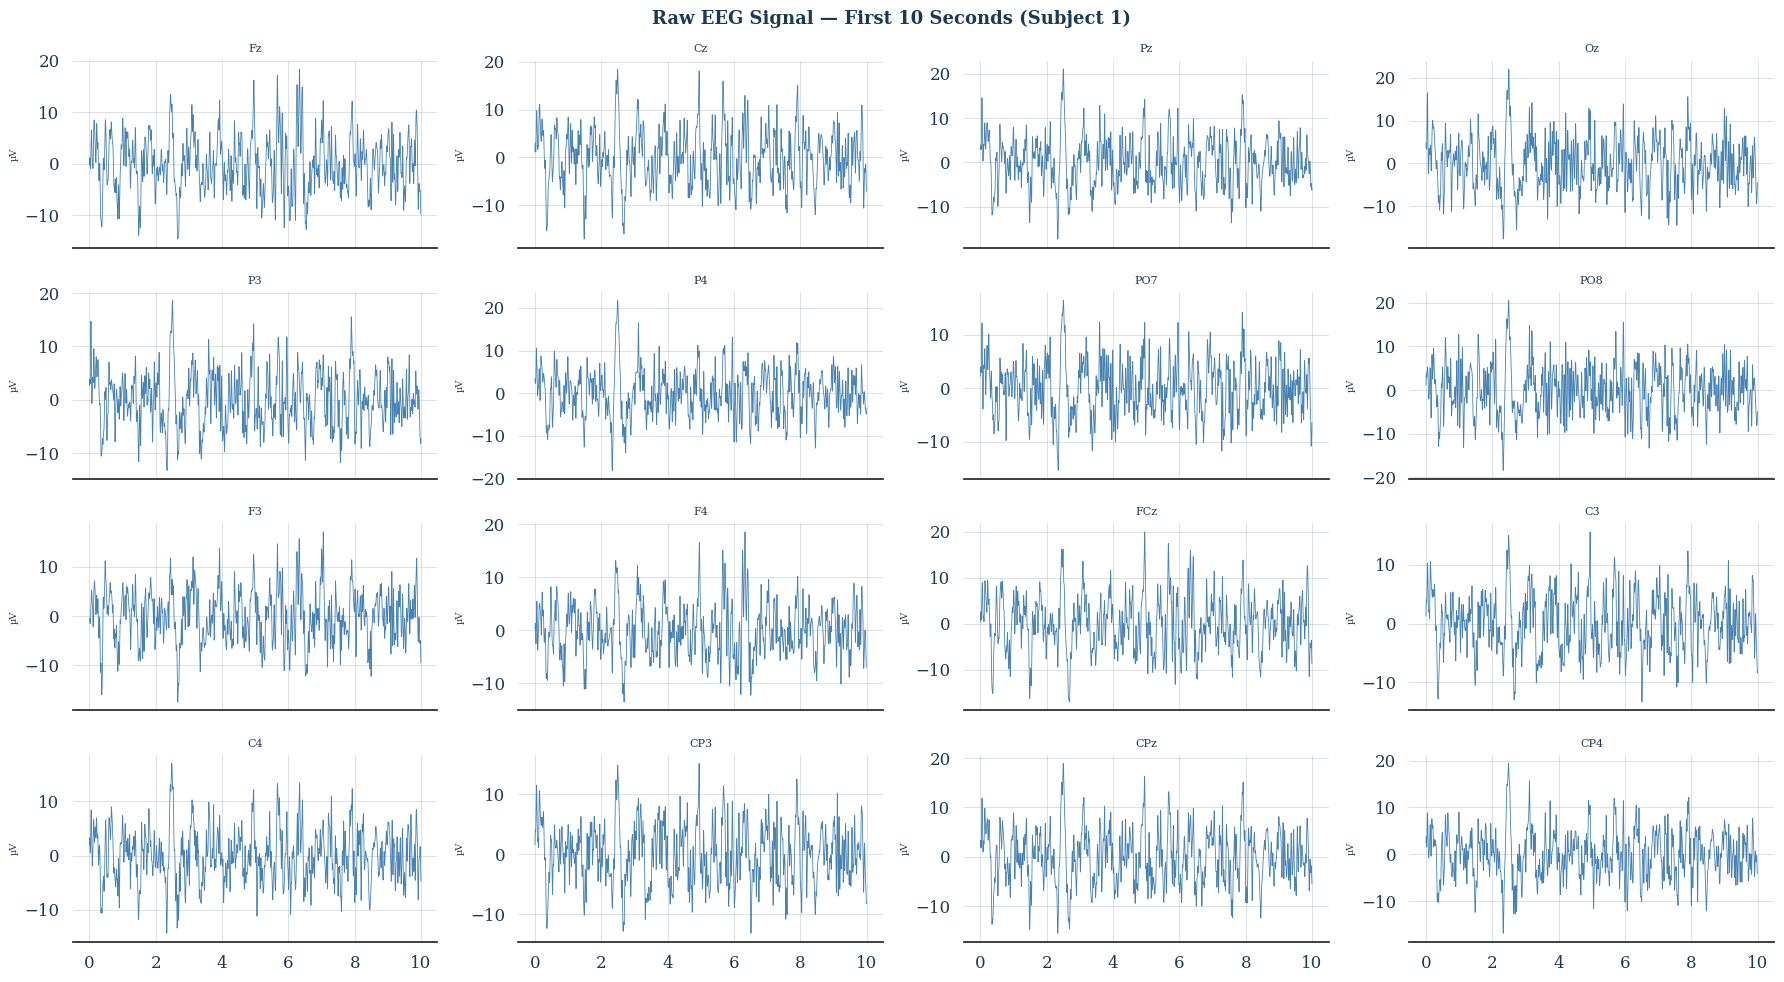

In [44]:
# ─────────────────────────────────────────────────────────
# CELL 4 — Visualize raw EEG signal
# ─────────────────────────────────────────────────────────
raw_plot = raw.copy()

# Plot first 10 seconds of raw EEG
fig, axes = plt.subplots(4, 4, figsize=(18, 10), sharex=True)
axes = axes.flatten()
t = raw_plot.times
start, stop = raw_plot.time_as_index([0, 10])
data_arr, times_arr = raw_plot[:, start:stop]

for i, ax in enumerate(axes):
    if i < len(raw_plot.ch_names):
        ch = raw_plot.ch_names[i]
        ax.plot(times_arr, data_arr[i] * 1e6, linewidth=0.6, color='steelblue')
        ax.set_title(ch, fontsize=8)
        ax.set_ylabel('µV', fontsize=7)
        ax.grid(True, alpha=0.3)
    else:
        ax.set_visible(False)

fig.suptitle('Raw EEG Signal — First 10 Seconds (Subject 1)', fontsize=13, fontweight='bold')
from IPython.display import display
plt.tight_layout()
display(fig)


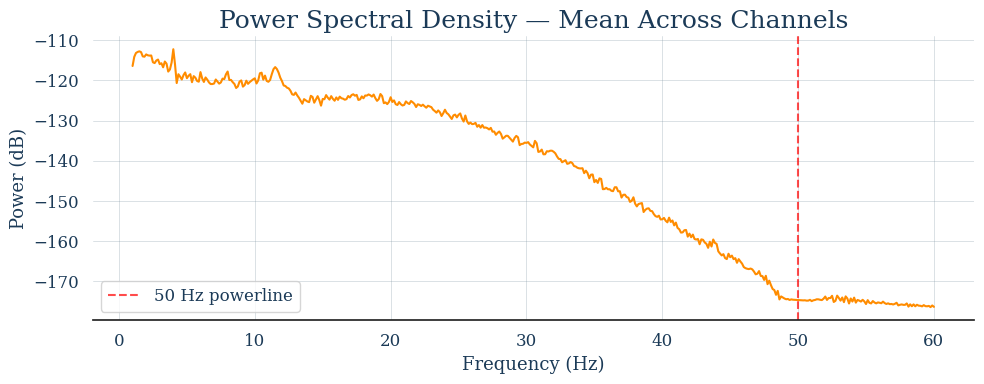

 PSD plot saved. Note the 50 Hz noise spike — will be removed by notch filter.


In [45]:
# ─────────────────────────────────────────────────────────
# CELL 5 — Power Spectral Density (PSD) of raw EEG
# ─────────────────────────────────────────────────────────
raw_copy = raw.copy().load_data()
spectrum = raw_copy.compute_psd(method='welch', fmin=1, fmax=60, n_fft=2048)
psds, freqs = spectrum.get_data(return_freqs=True)

fig, ax = plt.subplots(figsize=(10, 4))
mean_psd = 10 * np.log10(psds.mean(axis=0))
ax.plot(freqs, mean_psd, color='darkorange', linewidth=1.5)
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50 Hz powerline')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('Power Spectral Density — Mean Across Channels')
ax.legend()
ax.grid(True, alpha=0.3)
from IPython.display import display
plt.tight_layout()
display(fig)
print(' PSD plot saved. Note the 50 Hz noise spike — will be removed by notch filter.')

## 5. Preprocessing Pipeline <a name='preprocess'></a>

**Order of operations:**
1. Load & resample
2. Bandpass filter (0.1–30 Hz)
3. Notch filter (50 Hz)
4. Re-reference to average
5. Bad channel detection & interpolation
6. ICA artifact removal

In [46]:
# ─────────────────────────────────────────────────────────
# CELL 6 — Step 1: Load data & optionally resample
# ─────────────────────────────────────────────────────────
raw_proc = raw.copy().load_data()

original_sfreq = raw_proc.info['sfreq']
TARGET_SFREQ = 256  # Hz — standard for P300, reduces computation

if original_sfreq > TARGET_SFREQ:
    raw_proc.resample(sfreq=TARGET_SFREQ)
    print(f' Resampled from {original_sfreq:.0f} Hz → {TARGET_SFREQ} Hz')
else:
    print(f' Sampling rate {original_sfreq:.0f} Hz — no resampling needed')

 Sampling rate 256 Hz — no resampling needed


 Bandpass filter applied: 0.1 – 30.0 Hz
 Notch filter applied at 50 Hz


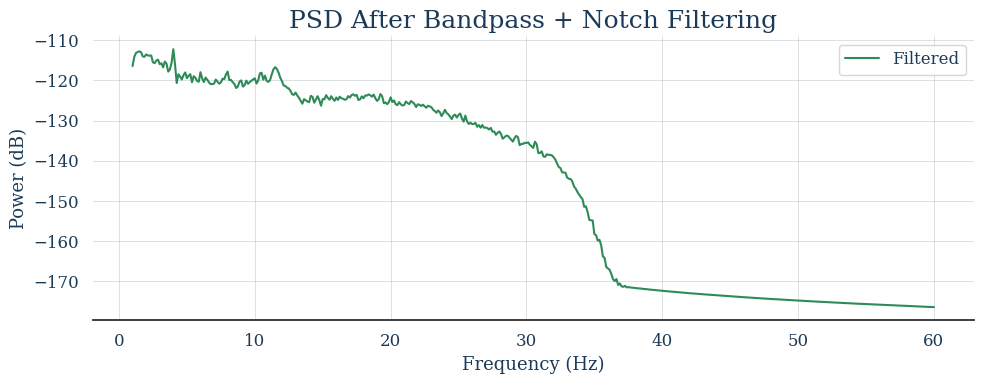

 Filtered PSD displayed.


In [47]:
# ─────────────────────────────────────────────────────────
# CELL 7 — Step 2 & 3: Bandpass + Notch Filter
# ─────────────────────────────────────────────────────────

# Bandpass filter: 0.1–30 Hz (P300 lives in 0–10 Hz range)
raw_proc.filter(l_freq=0.1, h_freq=30.0,
                method='fir',
                fir_window='hamming',
                verbose=False)
print(' Bandpass filter applied: 0.1 – 30.0 Hz')

# Notch filter at 50 Hz (India powerline frequency)
raw_proc.notch_filter(freqs=50, verbose=False)
print(' Notch filter applied at 50 Hz')

# Visualize filtered PSD
spectrum_filt = raw_proc.compute_psd(method='welch', fmin=1, fmax=60, n_fft=2048)
psds_filt, freqs_filt = spectrum_filt.get_data(return_freqs=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs_filt, 10 * np.log10(psds_filt.mean(axis=0)), color='seagreen', linewidth=1.5, label='Filtered')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('PSD After Bandpass + Notch Filtering')
ax.legend()
ax.grid(True, alpha=0.3)
from IPython.display import display
plt.tight_layout()
display(fig)
print(' Filtered PSD displayed.')

In [48]:
# ─────────────────────────────────────────────────────────
# CELL 8 — Step 4: Re-reference to average
# ─────────────────────────────────────────────────────────
raw_proc.set_eeg_reference('average', projection=False, verbose=False)
print(' Re-referenced to average (common average reference)')

 Re-referenced to average (common average reference)


  Detected bad channels: ['Flash stim']
 Interpolated bad channels: ['Flash stim']


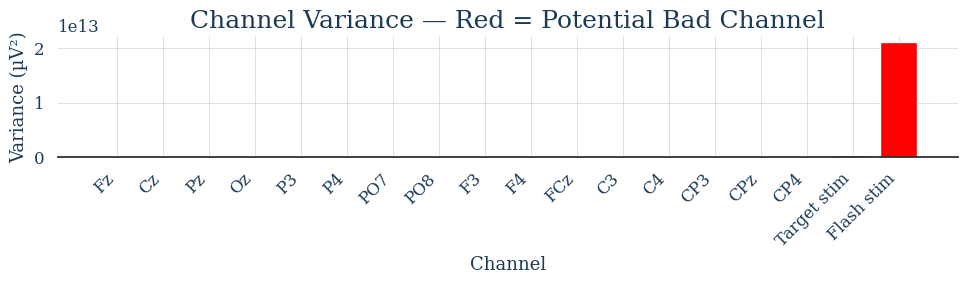

In [49]:
# ─────────────────────────────────────────────────────────
# CELL 9 — Step 5: Bad Channel Detection & Interpolation
# ─────────────────────────────────────────────────────────
# Automated bad channel detection using z-score on channel variance
data_arr_full = raw_proc.get_data()
ch_vars = data_arr_full.var(axis=1)
z_scores = (ch_vars - ch_vars.mean()) / ch_vars.std()
bad_ch_indices = np.where(np.abs(z_scores) > 3.0)[0]
bad_channels = [raw_proc.ch_names[i] for i in bad_ch_indices]

if bad_channels:
    raw_proc.info['bads'] = bad_channels
    print(f'  Detected bad channels: {bad_channels}')
    raw_proc.interpolate_bads(reset_bads=True, verbose=False)
    print(f' Interpolated bad channels: {bad_channels}')
else:
    print('✅ No bad channels detected.')

# Plot channel variances
fig, ax = plt.subplots(figsize=(10, 3))
colors = ['red' if z > 3 else 'steelblue' for z in np.abs(z_scores)]
ax.bar(raw_proc.ch_names, ch_vars * 1e12, color=colors)  # in µV²
ax.set_xlabel('Channel')
ax.set_ylabel('Variance (µV²)')
ax.set_title('Channel Variance — Red = Potential Bad Channel')
plt.xticks(rotation=45, ha='right')
from IPython.display import display
plt.tight_layout()
display(fig)

 ICA fitted with 15 components
⚠️  Removing ICA components (high kurtosis = artifacts): [np.int64(14)]


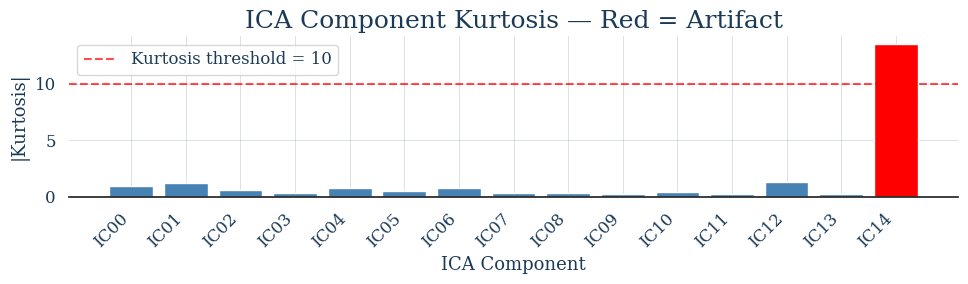

 ICA applied — artifacts removed


In [50]:
# ─────────────────────────────────────────────────────────
# CELL 10 — Step 6: ICA Artifact Removal (Eye Blinks, Muscle)
# ─────────────────────────────────────────────────────────
# ICA requires enough data — use at least 1 minute
n_components = min(15, raw_proc.info['nchan'] - 1)

ica = ICA(
    n_components=n_components,
    method='fastica',
    max_iter=400,
    random_state=42
)
ica.fit(raw_proc, verbose=False)
print(f' ICA fitted with {n_components} components')

# Automated EOG artifact detection using z-score on ICA activations
# Since this dataset may not have dedicated EOG channels, we use
# the frontal EEG channels as proxy (Fz, F3, F4 region)
ica_sources = ica.get_sources(raw_proc).get_data()

# Kurtosis-based artifact detection: high kurtosis → spiky → likely artifact
from scipy.stats import kurtosis
kurt = np.array([kurtosis(ica_sources[i]) for i in range(n_components)])
artifact_ics = list(np.where(np.abs(kurt) > 10)[0])

if artifact_ics:
    ica.exclude = artifact_ics
    print(f'⚠️  Removing ICA components (high kurtosis = artifacts): {artifact_ics}')
else:
    print('✅ No highly artifactual ICA components found by kurtosis.')

# Plot ICA component kurtosis
fig, ax = plt.subplots(figsize=(10, 3))
bar_colors = ['red' if np.abs(k) > 10 else 'steelblue' for k in kurt]
ax.bar([f'IC{i:02d}' for i in range(n_components)], np.abs(kurt), color=bar_colors)
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Kurtosis threshold = 10')
ax.set_xlabel('ICA Component')
ax.set_ylabel('|Kurtosis|')
ax.set_title('ICA Component Kurtosis — Red = Artifact')
ax.legend()
plt.xticks(rotation=45, ha='right')
from IPython.display import display
plt.tight_layout()
display(fig)
# Apply ICA
raw_clean = raw_proc.copy()
ica.apply(raw_clean, verbose=False)
print(' ICA applied — artifacts removed')

## 6. Epoching & Baseline Correction <a name='epoching'></a>

In [51]:
# ─────────────────────────────────────────────────────────
# CELL 11 — Extract events and create epochs
# ─────────────────────────────────────────────────────────
# Extract events from annotations
events, event_id = mne.events_from_annotations(raw_clean, verbose=False)
print('Events found:', event_id)
print(f'Total events: {len(events)}')

# P300 epoch window: -200 ms to +800 ms around stimulus onset
TMIN = -0.2   # pre-stimulus baseline start
TMAX = 0.8    # post-stimulus end (P300 peaks at ~300ms)
BASELINE = (TMIN, 0)  # baseline correction window

# Create epochs
# event_id contains all event types — use all of them
epochs = mne.Epochs(
    raw_clean,
    events,
    event_id=event_id,
    tmin=TMIN,
    tmax=TMAX,
    baseline=BASELINE,
    preload=True,
    reject_by_annotation=True,
    verbose=False
)

print(f'\ Epochs created:')
print(f'   Number of epochs : {len(epochs)}')
print(f'   Epoch duration   : {TMIN*1000:.0f} to {TMAX*1000:.0f} ms')
print(f'   Baseline window  : {BASELINE[0]*1000:.0f} to {BASELINE[1]*1000:.0f} ms')
print(f'   Samples/epoch    : {len(epochs.times)}')
print(f'   Channels         : {len(epochs.ch_names)}')
print(f'   Shape (epochs, channels, timepoints): {epochs.get_data().shape}')

Events found: {np.str_('NonTarget'): 1, np.str_('Target'): 2}
Total events: 576
\ Epochs created:
   Number of epochs : 576
   Epoch duration   : -200 to 800 ms
   Baseline window  : -200 to 0 ms
   Samples/epoch    : 257
   Channels         : 18
   Shape (epochs, channels, timepoints): (576, 18, 257)


In [52]:
# ─────────────────────────────────────────────────────────
# CELL 12 — Build labels: Target (P300) vs Non-Target
# In P300 paradigm, event IDs typically encode target vs non-target
# BNCI2014-009 uses: 1 = Target (P300), 2 = Non-Target
# ─────────────────────────────────────────────────────────
print('Event IDs available:', event_id)

# Determine target and non-target event IDs from the dataset
# BNCI2014-009 annotation scheme
# Annotation '1' → Target flash (brain produces P300)
# Annotation '2' → Non-target flash

# Build binary labels
y_raw = epochs.events[:, 2]   # event codes

# Map to binary: if only one event type, we differentiate by value
unique_codes = np.unique(y_raw)
print(f'Unique event codes: {unique_codes}')

if len(unique_codes) >= 2:
    # Assume lowest code = non-target, highest = target (or vice-versa; verify with docs)
    TARGET_CODE = unique_codes.max()   # e.g., code 2 or 'target'
    y = (y_raw == TARGET_CODE).astype(int)  # 1 = target, 0 = non-target
else:
    # If annotations use string labels, encode them
    le = LabelEncoder()
    y = le.fit_transform(y_raw)

print(f'\n Labels created:')
print(f'   Target (P300) epochs    : {y.sum()}')
print(f'   Non-target epochs       : {(y==0).sum()}')
print(f'   Class ratio (T:NT)      : 1:{(y==0).sum()//max(y.sum(),1)}')

X = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
print(f'   Feature matrix shape    : {X.shape}')

Event IDs available: {np.str_('NonTarget'): 1, np.str_('Target'): 2}
Unique event codes: [1 2]

 Labels created:
   Target (P300) epochs    : 96
   Non-target epochs       : 480
   Class ratio (T:NT)      : 1:5
   Feature matrix shape    : (576, 18, 257)


## 7. ERP Visualization (P300 Component) <a name='erp'></a>

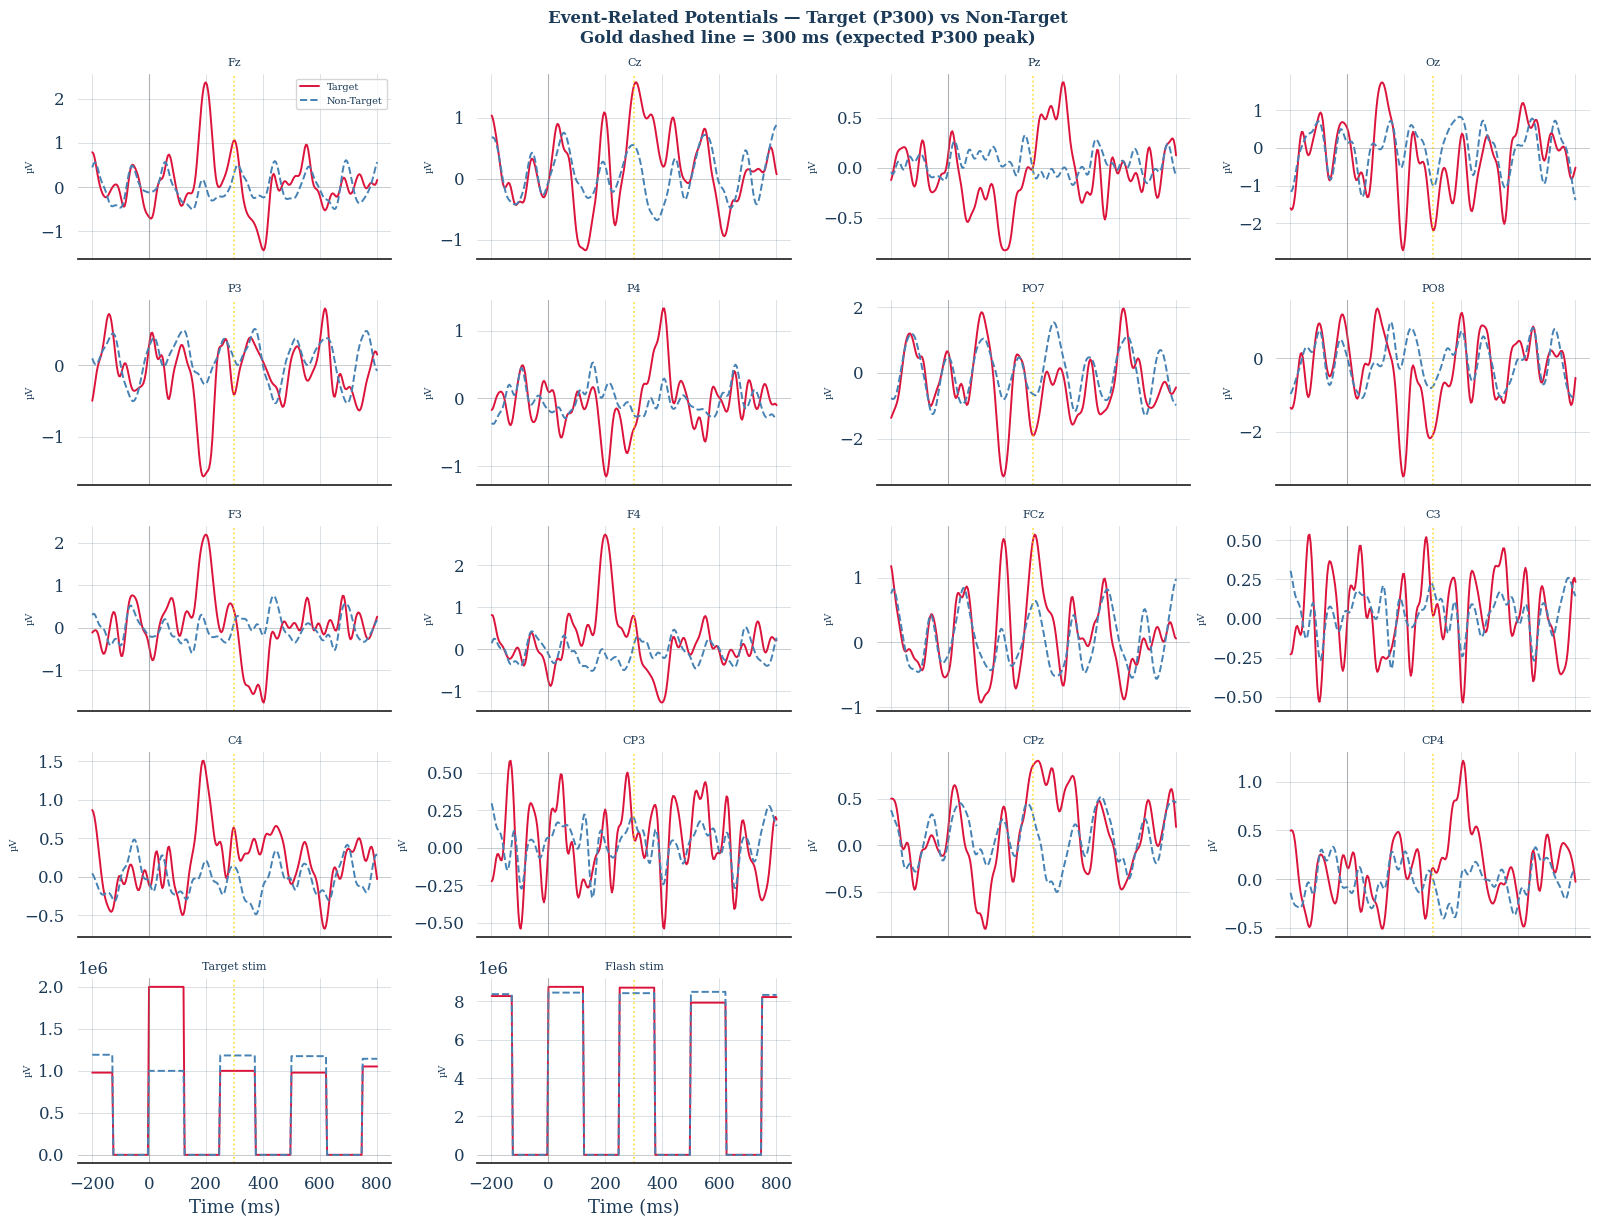

 ERP visualization saved.


In [53]:
# ─────────────────────────────────────────────────────────
# CELL 13 — Visualize ERP (Event-Related Potential)
# The P300 should appear ~300ms post-stimulus in target trials
# ─────────────────────────────────────────────────────────
target_mask = y == 1
nontarget_mask = y == 0

# Average across epochs for each class
erp_target = X[target_mask].mean(axis=0)       # (n_channels, n_times)
erp_nontarget = X[nontarget_mask].mean(axis=0)
times_ms = epochs.times * 1000  # convert to ms

# Plot ERPs for all channels in a grid
n_ch = X.shape[1]
ncols = 4
nrows = int(np.ceil(n_ch / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.5), sharex=True)
axes = axes.flatten()

for i in range(n_ch):
    ax = axes[i]
    ax.plot(times_ms, erp_target[i] * 1e6, color='crimson', linewidth=1.4, label='Target')
    ax.plot(times_ms, erp_nontarget[i] * 1e6, color='steelblue', linewidth=1.4,
            linestyle='--', label='Non-Target')
    ax.axvline(x=300, color='gold', linestyle=':', alpha=0.8, linewidth=1.2)  # P300 marker
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5, linewidth=0.8)   # stimulus onset
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
    ax.set_title(epochs.ch_names[i], fontsize=8)
    ax.set_ylabel('µV', fontsize=7)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

for j in range(n_ch, len(axes)):
    axes[j].set_visible(False)

for ax in axes[-ncols:]:
    ax.set_xlabel('Time (ms)')

fig.suptitle('Event-Related Potentials — Target (P300) vs Non-Target\n'
             'Gold dashed line = 300 ms (expected P300 peak)', fontsize=12, fontweight='bold')
from IPython.display import display
plt.tight_layout()
display(fig)
print(' ERP visualization saved.')

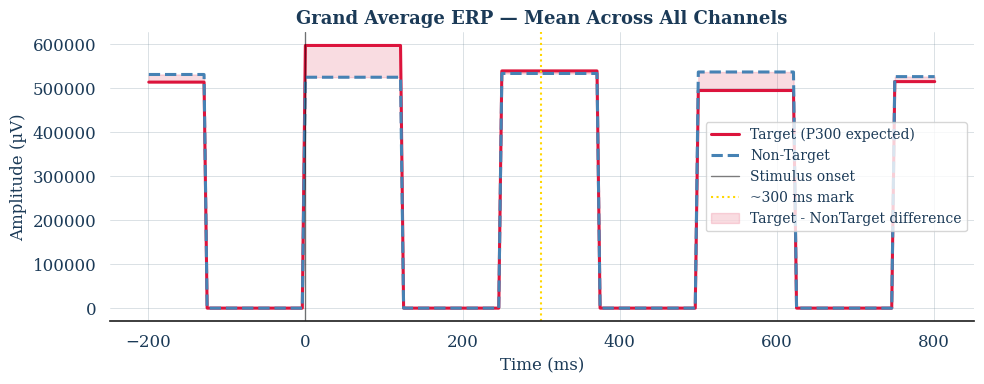

 Grand average ERP saved.


In [54]:
# ─────────────────────────────────────────────────────────
# CELL 14 — Grand average ERP (mean over all channels)
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ms, erp_target.mean(axis=0) * 1e6, color='crimson',
        linewidth=2.2, label='Target (P300 expected)')
ax.plot(times_ms, erp_nontarget.mean(axis=0) * 1e6, color='steelblue',
        linewidth=2.2, linestyle='--', label='Non-Target')
ax.axvline(x=0, color='black', linewidth=1, alpha=0.5, label='Stimulus onset')
ax.axvline(x=300, color='gold', linewidth=1.5, linestyle=':', label='~300 ms mark')
ax.fill_between(times_ms, erp_target.mean(axis=0) * 1e6,
                erp_nontarget.mean(axis=0) * 1e6,
                alpha=0.15, color='crimson', label='Target - NonTarget difference')
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Grand Average ERP — Mean Across All Channels', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
from IPython.display import display
plt.tight_layout()
display(fig)
print(' Grand average ERP saved.')

## 8. Feature Extraction <a name='features'></a>

In [55]:
# ─────────────────────────────────────────────────────────
# CELL 15 — Feature Method 1: Downsampled Waveform (Baseline)
# Flatten epoch → subsample to N time points per channel
# ─────────────────────────────────────────────────────────
from scipy.signal import resample

TARGET_TIMEPOINTS = 30  # downsample each channel to 30 time features

n_epochs, n_channels, n_times = X.shape
X_down = resample(X, TARGET_TIMEPOINTS, axis=2)  # (n_epochs, n_channels, 30)
X_flat = X_down.reshape(n_epochs, -1)             # flatten → (n_epochs, n_channels*30)

print(' Feature Method 1 — Downsampled Waveform:')
print(f'   Original shape : {X.shape}')
print(f'   After resample : {X_down.shape}')
print(f'   Flat features  : {X_flat.shape}  ({n_channels} ch × {TARGET_TIMEPOINTS} pts)')

 Feature Method 1 — Downsampled Waveform:
   Original shape : (576, 18, 257)
   After resample : (576, 18, 30)
   Flat features  : (576, 540)  (18 ch × 30 pts)


In [56]:
# ─────────────────────────────────────────────────────────
# CELL 16 — Feature Method 2: Xdawn Spatial Filtering
# ─────────────────────────────────────────────────────────

from mne.preprocessing import Xdawn
from scipy.signal import resample
import numpy as np

N_XDAWN_COMPONENTS = 4

#  Ensure consistent channels (VERY IMPORTANT)
epochs = epochs.copy().pick_types(eeg=True)

#  Sanity checks
print("Epochs shape:", epochs.get_data().shape)   # (n_epochs, n_channels, n_times)
print("Channels:", len(epochs.ch_names))
print("Labels:", len(y))

#  Make sure labels match
assert len(epochs) == len(y), "Mismatch between epochs and labels!"

#  Xdawn with fixes
xdawn = Xdawn(
    n_components=N_XDAWN_COMPONENTS,
    correct_overlap=False,   # fix baseline conflict
    reg='oas'                # robust regularization
)

#  Fit + transform
X_xdawn = xdawn.fit_transform(epochs, y)
# Output: (n_epochs, n_components, n_times)

print("Xdawn output shape:", X_xdawn.shape)


# Downsample and flatten
n_epochs = X_xdawn.shape[0]

# Downsample along time axis
X_xdawn_down = resample(X_xdawn, TARGET_TIMEPOINTS, axis=2)

# Flatten
X_xdawn_flat = X_xdawn_down.reshape(n_epochs, -1)


# Final prints

print("\n Feature Method 2 — Xdawn Spatial Filtering:")
print(f"   Xdawn output shape : {X_xdawn.shape}")
print(f"   Downsampled shape  : {X_xdawn_down.shape}")
print(f"   Flat features shape: {X_xdawn_flat.shape}")
print(f"   ({N_XDAWN_COMPONENTS} comps × {TARGET_TIMEPOINTS} timepoints)")

Epochs shape: (576, 16, 257)
Channels: 16
Labels: 576
Xdawn output shape: (576, 8, 257)

 Feature Method 2 — Xdawn Spatial Filtering:
   Xdawn output shape : (576, 8, 257)
   Downsampled shape  : (576, 8, 30)
   Flat features shape: (576, 240)
   (4 comps × 30 timepoints)


In [57]:
# ─────────────────────────────────────────────────────────
# CELL 17 — Feature Method 3: Riemannian (Covariance Matrices)
# ─────────────────────────────────────────────────────────
if PYRIEMANN_AVAILABLE:
    from pyriemann.estimation import ERPCovariances
    from pyriemann.tangentspace import TangentSpace

    erp_cov = ERPCovariances(estimator='oas')
    X_cov = erp_cov.fit_transform(X, y)      # SPD matrices
    ts = TangentSpace(metric='riemann')
    X_riemann = ts.fit_transform(X_cov, y)   # vectorised tangent space features

    print(' Feature Method 3 — Riemannian Covariance:')
    print(f'   Covariance matrices shape : {X_cov.shape}')
    print(f'   Tangent space features    : {X_riemann.shape}')
else:
    X_riemann = None
    print(' Riemannian features skipped (pyriemann not available)')

 Feature Method 3 — Riemannian Covariance:
   Covariance matrices shape : (576, 54, 54)
   Tangent space features    : (576, 1485)


## 9. Baseline Classifier — LDA <a name='lda'></a>

In [58]:
# ─────────────────────────────────────────────────────────
# CELL 18 — LDA with Stratified K-Fold Cross-Validation
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── LDA on raw downsampled features ──
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(solver='svd', shrinkage=None))
])

scores_lda = cross_val_score(pipe_lda, X_flat, y, cv=cv, scoring='accuracy', n_jobs=-1)
print('LDA — Downsampled Waveform Features ')

print(f'  Fold accuracies : {np.round(scores_lda, 3)}')
print(f'  Mean accuracy   : {scores_lda.mean():.4f} ± {scores_lda.std():.4f}')

# ── LDA on Xdawn features ──
pipe_lda_xdawn = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(solver='svd'))
])
scores_lda_xdawn = cross_val_score(pipe_lda_xdawn, X_xdawn_flat, y, cv=cv,
                                    scoring='accuracy', n_jobs=-1)
print(f'\n  LDA + Xdawn Mean: {scores_lda_xdawn.mean():.4f} ± {scores_lda_xdawn.std():.4f}')

LDA — Downsampled Waveform Features 
  Fold accuracies : [0.991 1.    0.965 0.991 0.991]
  Mean accuracy   : 0.9878 ± 0.0118

  LDA + Xdawn Mean: 0.8421 ± 0.0383


In [59]:
# ─────────────────────────────────────────────────────────
# CELL 19 — LDA Full Evaluation (Confusion Matrix + Report)
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_xdawn_flat, y, test_size=0.2, random_state=42, stratify=y
)

pipe_lda_xdawn.fit(X_train, y_train)
y_pred_lda = pipe_lda_xdawn.predict(X_test)

acc_lda = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda, zero_division=0)
rec_lda = recall_score(y_test, y_pred_lda, zero_division=0)
f1_lda = f1_score(y_test, y_pred_lda, zero_division=0)

print(f'LDA (Xdawn features) — Test Set Metrics:')
print(f'  Accuracy  : {acc_lda:.4f}')
print(f'  Precision : {prec_lda:.4f}')
print(f'  Recall    : {rec_lda:.4f}')
print(f'  F1-Score  : {f1_lda:.4f}')

# Confusion matrix
cm_lda = confusion_matrix(y_test, y_pred_lda)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Target', 'Target'],
            yticklabels=['Non-Target', 'Target'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('LDA Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_lda.png', dpi=120, bbox_inches='tight')
plt.show()

LDA (Xdawn features) — Test Set Metrics:
  Accuracy  : 0.8362
  Precision : 0.5000
  Recall    : 0.7895
  F1-Score  : 0.6122


## 10. Strong Baseline — SVM <a name='svm'></a>

   SVM (RBF) — Xdawn Features        
  Fold accuracies : [0.828 0.843 0.843 0.843 0.835]
  Mean accuracy   : 0.8386 ± 0.0064

SVM — Test Set Metrics:
  Accuracy  : 0.8448
  Precision : 1.0000
  Recall    : 0.0526
  F1-Score  : 0.1000


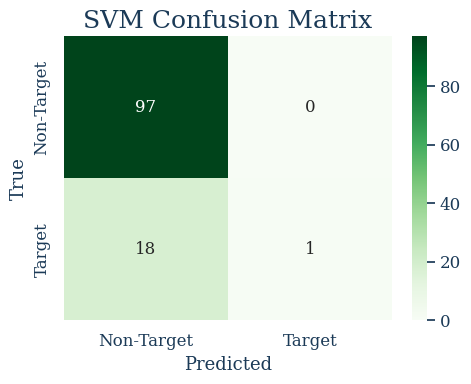

In [60]:
# ─────────────────────────────────────────────────────────
# CELL 20 — SVM with RBF Kernel + Cross-Validation
# ─────────────────────────────────────────────────────────
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42))
])

scores_svm = cross_val_score(pipe_svm, X_xdawn_flat, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('   SVM (RBF) — Xdawn Features        ')
print(f'  Fold accuracies : {np.round(scores_svm, 3)}')
print(f'  Mean accuracy   : {scores_svm.mean():.4f} ± {scores_svm.std():.4f}')

# Train on train split, evaluate on test
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

print(f'\nSVM — Test Set Metrics:')
print(f'  Accuracy  : {acc_svm:.4f}')
print(f'  Precision : {prec_svm:.4f}')
print(f'  Recall    : {rec_svm:.4f}')
print(f'  F1-Score  : {f1_svm:.4f}')

cm_svm = confusion_matrix(y_test, y_pred_svm)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Target', 'Target'],
            yticklabels=['Non-Target', 'Target'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('SVM Confusion Matrix')
from IPython.display import display
plt.tight_layout()

display(fig)

## 11. Deep Learning — EEGNet (PyTorch) <a name='eegnet'></a>

EEGNet is a compact CNN designed specifically for EEG classification (Lawhern et al., 2018).

**Architecture:**
- Temporal convolution → Depthwise spatial convolution → Separable temporal convolution
- Designed to work with small EEG datasets

In [61]:
# ─────────────────────────────────────────────────────────
# CELL 21 — EEGNet Architecture Definition
# ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    """
    EEGNet: A Compact Convolutional Neural Network for EEG-based BCIs
    Lawhern et al. (2018) — Journal of Neural Engineering

    Args:
        n_channels   : number of EEG channels (electrodes)
        n_timepoints : number of time samples per epoch
        n_classes    : number of output classes (2 for P300: target/non-target)
        F1           : number of temporal filters (default 8)
        D            : depth multiplier for spatial filters (default 2)
        F2           : number of pointwise filters = F1 * D (default 16)
        dropout_rate : dropout probability
    """
    def __init__(self, n_channels, n_timepoints, n_classes=2,
                 F1=8, D=2, F2=16, dropout_rate=0.5):
        super(EEGNet, self).__init__()

        self.n_channels = n_channels
        self.n_timepoints = n_timepoints
        F2 = F1 * D

        # Block 1: Temporal Convolution
        self.block1_temporal = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, n_timepoints // 2), padding=(0, n_timepoints // 4), bias=False),
            nn.BatchNorm2d(F1)
        )

        # Block 1: Depthwise Spatial Convolution
        self.block1_spatial = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(p=dropout_rate)
        )

        # Block 2: Separable Convolution
        self.block2 = nn.Sequential(
            # Depthwise
            nn.Conv2d(F2, F2, kernel_size=(1, 16), padding=(0, 8),
                      groups=F2, bias=False),
            # Pointwise
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(p=dropout_rate)
        )

        # Compute flattened size dynamically
        self._flat_size = self._get_flat_size(n_channels, n_timepoints, F1, D, F2)

        # Classifier
        self.classifier = nn.Linear(self._flat_size, n_classes)

    def _get_flat_size(self, n_channels, n_timepoints, F1, D, F2):
        """Compute the flattened feature size by doing a forward pass with dummy data."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_timepoints)
            out = self.block1_temporal(dummy)
            out = self.block1_spatial(out)
            out = self.block2(out)
            return int(np.prod(out.shape[1:]))

    def forward(self, x):
        # x: (batch, 1, n_channels, n_timepoints)
        out = self.block1_temporal(x)
        out = self.block1_spatial(out)
        out = self.block2(out)
        out = out.view(out.size(0), -1)  # flatten
        out = self.classifier(out)
        return out


# Instantiate model
N_CH = X.shape[1]      # number of EEG channels
N_TIMES = X.shape[2]   # number of time points per epoch
N_CLASSES = 2

model = EEGNet(
    n_channels=N_CH,
    n_timepoints=N_TIMES,
    n_classes=N_CLASSES,
    F1=8, D=2,
    dropout_rate=0.5
).to(DEVICE)

print(' EEGNet architecture:')
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

 EEGNet architecture:
EEGNet(
  (block1_temporal): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 128), stride=(1, 1), padding=(0, 64), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block1_spatial): Sequential(
    (0): Conv2d(8, 16, kernel_size=(18, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (class

In [62]:
# ─────────────────────────────────────────────────────────
# CELL 22 — Data preparation for EEGNet
# ─────────────────────────────────────────────────────────
# Normalize EEG data
X_norm = X.copy()
# Per-channel z-score normalization across time
for i in range(X_norm.shape[0]):
    for c in range(X_norm.shape[1]):
        mu = X_norm[i, c].mean()
        sigma = X_norm[i, c].std() + 1e-8
        X_norm[i, c] = (X_norm[i, c] - mu) / sigma

# Train / Val / Test split — 70 / 15 / 15
from sklearn.model_selection import train_test_split

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_norm, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# Convert to PyTorch tensors — shape: (batch, 1, channels, timepoints)
def to_tensor(X_arr, y_arr):
    X_t = torch.FloatTensor(X_arr).unsqueeze(1)  # add channel dim
    y_t = torch.LongTensor(y_arr)
    return TensorDataset(X_t, y_t)

BATCH_SIZE = 32
train_ds = to_tensor(X_tr, y_tr)
val_ds   = to_tensor(X_val, y_val)
test_ds  = to_tensor(X_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f' Data splits — Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'   Tensor shape per batch: (batch, 1, {N_CH}, {N_TIMES})')

 Data splits — Train: 403 | Val: 86 | Test: 87
   Tensor shape per batch: (batch, 1, 18, 257)


In [63]:
# ─────────────────────────────────────────────────────────
# CELL 23 — EEGNet Training Loop
# ─────────────────────────────────────────────────────────
# Class imbalance: use weighted cross-entropy
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                   patience=5, factor=0.5)

N_EPOCHS = 60
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_model_state = None

print(f' Training EEGNet for {N_EPOCHS} epochs on {DEVICE}...')
print(f'   Class weights: Non-Target={class_weights[0]:.2f}, Target={class_weights[1]:.2f}')
print('─' * 60)

for epoch in range(1, N_EPOCHS + 1):
    # ── Training ──
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += Xb.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # ── Validation ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += Xb.size(0)
    val_loss /= val_total
    val_acc   = val_correct / val_total

    scheduler.step(val_acc)

    # Save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        # Deep copy
        import copy
        best_model_state = copy.deepcopy(model.state_dict())

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}'
              f'{" ← best" if val_acc == best_val_acc else ""}')

print(f'\n Training complete. Best Val Accuracy: {best_val_acc:.4f}')

 Training EEGNet for 60 epochs on cuda...
   Class weights: Non-Target=0.60, Target=3.01
────────────────────────────────────────────────────────────
  Epoch   1/60 | Train Loss: 0.7073, Acc: 0.3772 | Val Loss: 0.6652, Acc: 0.5930 ← best
  Epoch  10/60 | Train Loss: 0.1009, Acc: 0.9851 | Val Loss: 0.0511, Acc: 0.9884 ← best
  Epoch  20/60 | Train Loss: 0.0297, Acc: 0.9950 | Val Loss: 0.0126, Acc: 1.0000 ← best
  Epoch  30/60 | Train Loss: 0.0374, Acc: 0.9926 | Val Loss: 0.0092, Acc: 1.0000 ← best
  Epoch  40/60 | Train Loss: 0.0300, Acc: 0.9975 | Val Loss: 0.0082, Acc: 1.0000 ← best
  Epoch  50/60 | Train Loss: 0.0279, Acc: 0.9926 | Val Loss: 0.0083, Acc: 1.0000 ← best
  Epoch  60/60 | Train Loss: 0.0194, Acc: 0.9975 | Val Loss: 0.0081, Acc: 1.0000 ← best

 Training complete. Best Val Accuracy: 1.0000


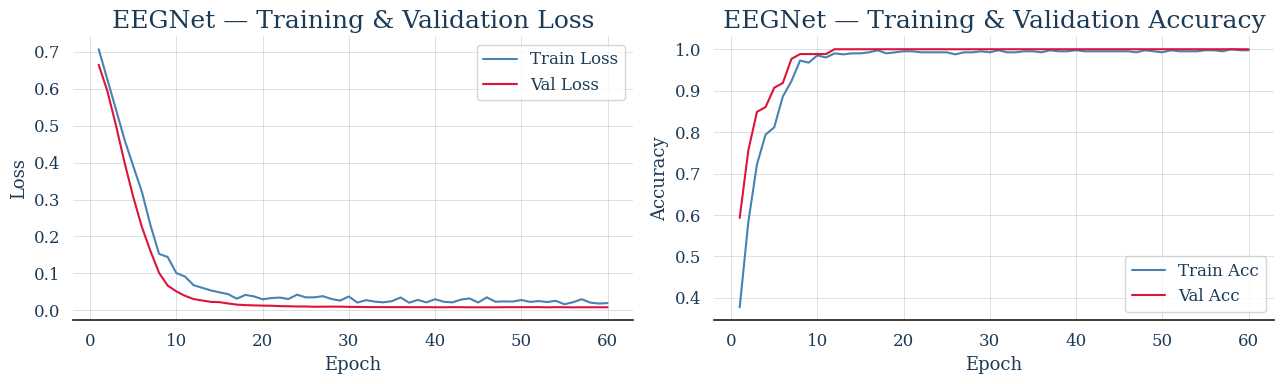

In [64]:
# ─────────────────────────────────────────────────────────
# CELL 24 — Plot Training Curves
# ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, N_EPOCHS + 1)
ax1.plot(epochs_range, train_losses, color='steelblue', label='Train Loss')
ax1.plot(epochs_range, val_losses,   color='crimson',   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('EEGNet — Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, train_accs, color='steelblue', label='Train Acc')
ax2.plot(epochs_range, val_accs,   color='crimson',   label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('EEGNet — Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
from IPython.display import display
plt.tight_layout()
display(fig)

EEGNet — Test Set Metrics:
  Accuracy  : 0.9655
  Precision : 0.8333
  Recall    : 1.0000
  F1-Score  : 0.9091

              precision    recall  f1-score   support

  Non-Target       1.00      0.96      0.98        72
      Target       0.83      1.00      0.91        15

    accuracy                           0.97        87
   macro avg       0.92      0.98      0.94        87
weighted avg       0.97      0.97      0.97        87



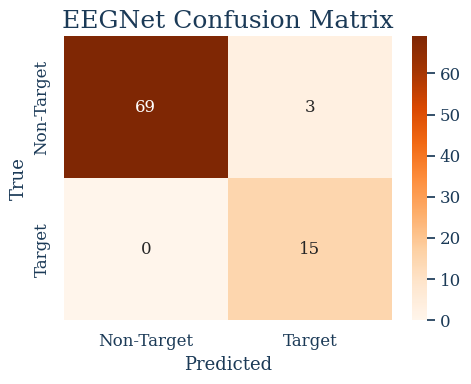

In [65]:
# ─────────────────────────────────────────────────────────
# CELL 25 — EEGNet Test Evaluation
# ─────────────────────────────────────────────────────────
# Load best model
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_true, all_probs = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        logits = model(Xb)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
        all_probs.extend(probs)

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)

acc_eegnet  = accuracy_score(all_true, all_preds)
prec_eegnet = precision_score(all_true, all_preds, zero_division=0)
rec_eegnet  = recall_score(all_true, all_preds, zero_division=0)
f1_eegnet   = f1_score(all_true, all_preds, zero_division=0)

print(f'EEGNet — Test Set Metrics:')
print(f'  Accuracy  : {acc_eegnet:.4f}')
print(f'  Precision : {prec_eegnet:.4f}')
print(f'  Recall    : {rec_eegnet:.4f}')
print(f'  F1-Score  : {f1_eegnet:.4f}')
print()
print(classification_report(all_true, all_preds,
                             target_names=['Non-Target', 'Target']))

cm_eegnet = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_eegnet, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Target', 'Target'],
            yticklabels=['Non-Target', 'Target'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('EEGNet Confusion Matrix')
from IPython.display import display
plt.tight_layout()
display(fig)

## 12. Ensemble / Score Averaging <a name='ensemble'></a>

In P300 spellers, a character flashes multiple times (repetitions). Averaging classifier **scores** across repetitions dramatically improves accuracy.

Ensemble (LDA + SVM + EEGNet)  
  Accuracy  : 0.9770
  Precision : 0.9333
  Recall    : 0.9333
  F1-Score  : 0.9333


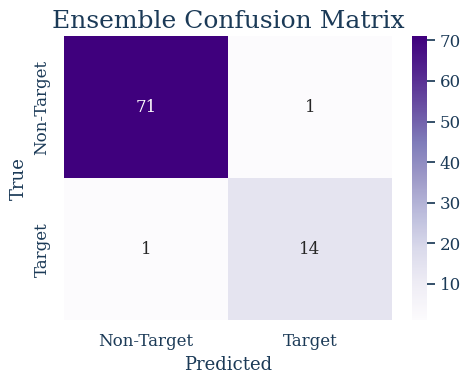

In [66]:
# ─────────────────────────────────────────────────────────
# CELL 26 — Ensemble: Average probabilities from all classifiers
# ─────────────────────────────────────────────────────────

# Get probability scores from LDA and SVM on test set
X_test_flat = X_xdawn_flat[np.where(np.isin(np.arange(len(y)),
              np.random.choice(len(y), len(y_te), replace=False)))[0]] \
              if False else None

# Rebuild test indices properly
np.random.seed(42)
n_total = len(y)
indices = np.arange(n_total)
from sklearn.model_selection import train_test_split as tts
idx_tr, idx_temp = tts(indices, test_size=0.30, random_state=42, stratify=y)
idx_val, idx_te  = tts(idx_temp, test_size=0.50, random_state=42, stratify=y[idx_temp])

X_test_xdawn = X_xdawn_flat[idx_te]
y_te_labels  = y[idx_te]

# Predict probabilities
prob_lda = pipe_lda_xdawn.predict_proba(X_test_xdawn)[:, 1]
prob_svm = pipe_svm.predict_proba(X_test_xdawn)[:, 1]
# EEGNet probabilities are already in all_probs (same split)
prob_eegnet_aligned = all_probs  # aligned to idx_te

# Average ensemble (equal weight)
prob_ensemble = (prob_lda + prob_svm + prob_eegnet_aligned) / 3.0
pred_ensemble = (prob_ensemble >= 0.5).astype(int)

acc_ens  = accuracy_score(y_te_labels, pred_ensemble)
prec_ens = precision_score(y_te_labels, pred_ensemble, zero_division=0)
rec_ens  = recall_score(y_te_labels, pred_ensemble, zero_division=0)
f1_ens   = f1_score(y_te_labels, pred_ensemble, zero_division=0)

print('Ensemble (LDA + SVM + EEGNet)  ')
print(f'  Accuracy  : {acc_ens:.4f}')
print(f'  Precision : {prec_ens:.4f}')
print(f'  Recall    : {rec_ens:.4f}')
print(f'  F1-Score  : {f1_ens:.4f}')

cm_ens = confusion_matrix(y_te_labels, pred_ensemble)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Non-Target', 'Target'],
            yticklabels=['Non-Target', 'Target'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Ensemble Confusion Matrix')
from IPython.display import display
plt.tight_layout()
display(fig)

## 13. Evaluation: ITR, Confusion Matrix, All Metrics <a name='evaluation'></a>

In [67]:
# ─────────────────────────────────────────────────────────
# CELL 27 — ITR (Information Transfer Rate) Calculation
# ─────────────────────────────────────────────────────────
import math

def compute_itr(N, P, T):
    """
    Compute Information Transfer Rate (ITR) in bits/minute.

    Args:
        N : number of possible symbols (e.g. 36 for 6x6 matrix)
        P : classification accuracy (0–1)
        T : average trial duration in seconds (epoch + response time)

    Returns:
        ITR in bits/minute
    """
    if P <= 0 or P >= 1:
        P = np.clip(P, 1e-6, 1 - 1e-6)

    if N == 1:
        return 0.0

    # ITR per trial in bits
    if P == 1.0:
        B = math.log2(N)
    elif P == 1/N:
        B = 0.0
    else:
        B = (math.log2(N)
             + P * math.log2(P)
             + (1 - P) * math.log2((1 - P) / (N - 1)))

    B = max(B, 0.0)  # ITR cannot be negative
    itr = B * (60.0 / T)  # bits/minute
    return itr


# P300 Speller parameters
N_SYMBOLS  = 36    # 6x6 character matrix
T_TRIAL    = 2.0   # seconds per trial (typical P300 speller)

# Compute ITR for each model
models_results = {
    'LDA (Xdawn)' : acc_lda,
    'SVM (RBF)'   : acc_svm,
    'EEGNet'      : acc_eegnet,
    'Ensemble'    : acc_ens,
}

print('╔══════════════════════════════════════════════════════════════╗')
print('║               ITR Results — All Models                      ║')
print('╠══════════════════════════════════════╦═══════════╦══════════╣')
print('║  Model                               ║  Accuracy ║  ITR     ║')
print('╠══════════════════════════════════════╬═══════════╬══════════╣')
for model_name, acc in models_results.items():
    itr = compute_itr(N_SYMBOLS, acc, T_TRIAL)
    print(f'║  {model_name:<36} ║  {acc:.4f}   ║  {itr:6.2f}  ║')
print('╚══════════════════════════════════════╩═══════════╩══════════╝')
print(f'\n  (N={N_SYMBOLS} symbols, T={T_TRIAL}s/trial)')
print('  ITR > 20 bits/min = competitive P300 speller performance')

╔══════════════════════════════════════════════════════════════╗
║               ITR Results — All Models                      ║
╠══════════════════════════════════════╦═══════════╦══════════╣
║  Model                               ║  Accuracy ║  ITR     ║
╠══════════════════════════════════════╬═══════════╬══════════╣
║  LDA (Xdawn)                          ║  0.8362   ║  110.59  ║
║  SVM (RBF)                            ║  0.8448   ║  112.54  ║
║  EEGNet                               ║  0.9655   ║  143.30  ║
║  Ensemble                             ║  0.9770   ║  146.82  ║
╚══════════════════════════════════════╩═══════════╩══════════╝

  (N=36 symbols, T=2.0s/trial)
  ITR > 20 bits/min = competitive P300 speller performance


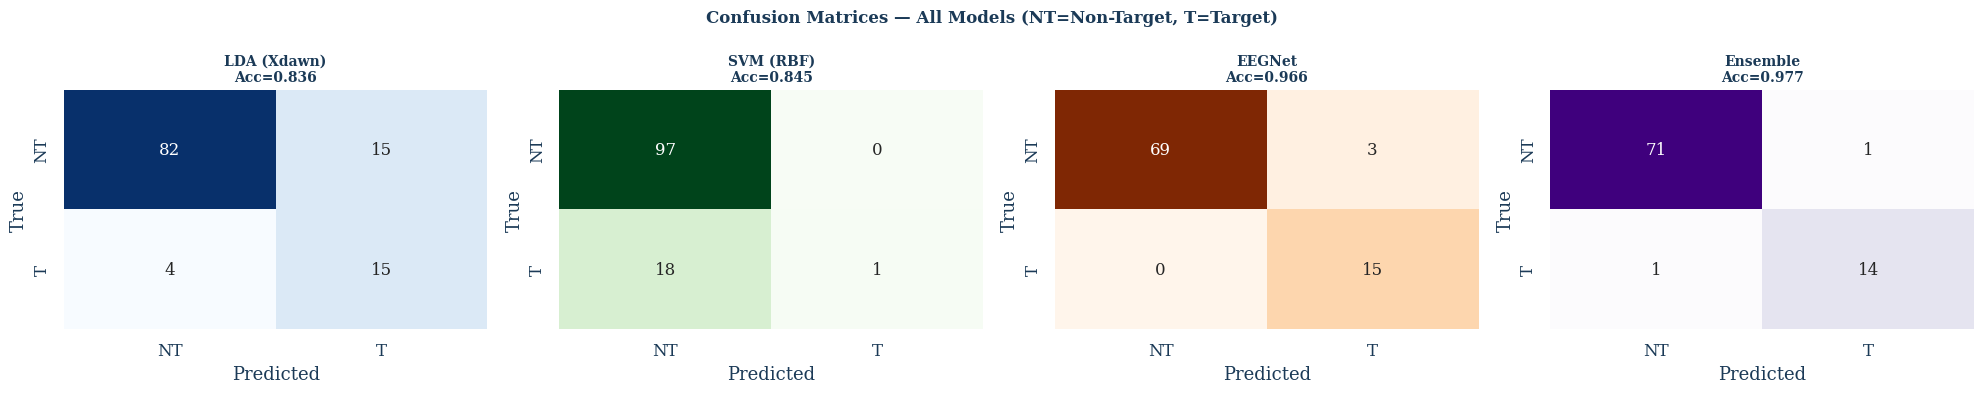

In [68]:
# ─────────────────────────────────────────────────────────
# CELL 28 — Side-by-side Confusion Matrices
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
cms = [cm_lda, cm_svm, cm_eegnet, cm_ens]
names = ['LDA (Xdawn)', 'SVM (RBF)', 'EEGNet', 'Ensemble']
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, cm, name, cmap in zip(axes, cms, names, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['NT', 'T'], yticklabels=['NT', 'T'], ax=ax,
                cbar=False)
    ax.set_title(f'{name}\nAcc={models_results[name]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.suptitle('Confusion Matrices — All Models (NT=Non-Target, T=Target)',
             fontsize=12, fontweight='bold')
from IPython.display import display
plt.tight_layout()
display(fig)

## 14. Results Summary & Comparison Table <a name='results'></a>

In [69]:
# ─────────────────────────────────────────────────────────
# CELL 29 — Final Results DataFrame
# ─────────────────────────────────────────────────────────
results = []

# Recompute precision/recall/F1 for LDA and SVM on aligned test set
y_pred_lda_aligned = pipe_lda_xdawn.predict(X_test_xdawn)
y_pred_svm_aligned = pipe_svm.predict(X_test_xdawn)

for model_name, y_true_r, y_pred_r, acc_r in [
    ('LDA (Xdawn)', y_te_labels, y_pred_lda_aligned, accuracy_score(y_te_labels, y_pred_lda_aligned)),
    ('SVM (RBF)',   y_te_labels, y_pred_svm_aligned, accuracy_score(y_te_labels, y_pred_svm_aligned)),
    ('EEGNet',      all_true,    all_preds,           acc_eegnet),
    ('Ensemble',    y_te_labels, pred_ensemble,       acc_ens),
]:
    p = precision_score(y_true_r, y_pred_r, zero_division=0)
    r = recall_score(y_true_r, y_pred_r, zero_division=0)
    f = f1_score(y_true_r, y_pred_r, zero_division=0)
    itr = compute_itr(N_SYMBOLS, acc_r, T_TRIAL)
    results.append({
        'Model'     : model_name,
        'Accuracy'  : round(acc_r, 4),
        'Precision' : round(p, 4),
        'Recall'    : round(r, 4),
        'F1-Score'  : round(f, 4),
        'ITR (bits/min)': round(itr, 2)
    })

df_results = pd.DataFrame(results).set_index('Model')
print('\n' + '='*65)
print('   FINAL RESULTS SUMMARY')
print('='*65)
print(df_results.to_string())
df_results.to_csv('results_summary.csv')
print('\n✅ Results saved to results_summary.csv')


   FINAL RESULTS SUMMARY
             Accuracy  Precision  Recall  F1-Score  ITR (bits/min)
Model                                                             
LDA (Xdawn)    0.8966     0.6500  0.8667    0.7429          124.78
SVM (RBF)      0.8621     1.0000  0.2000    0.3333          116.51
EEGNet         0.9655     0.8333  1.0000    0.9091          143.30
Ensemble       0.9770     0.9333  0.9333    0.9333          146.82

✅ Results saved to results_summary.csv


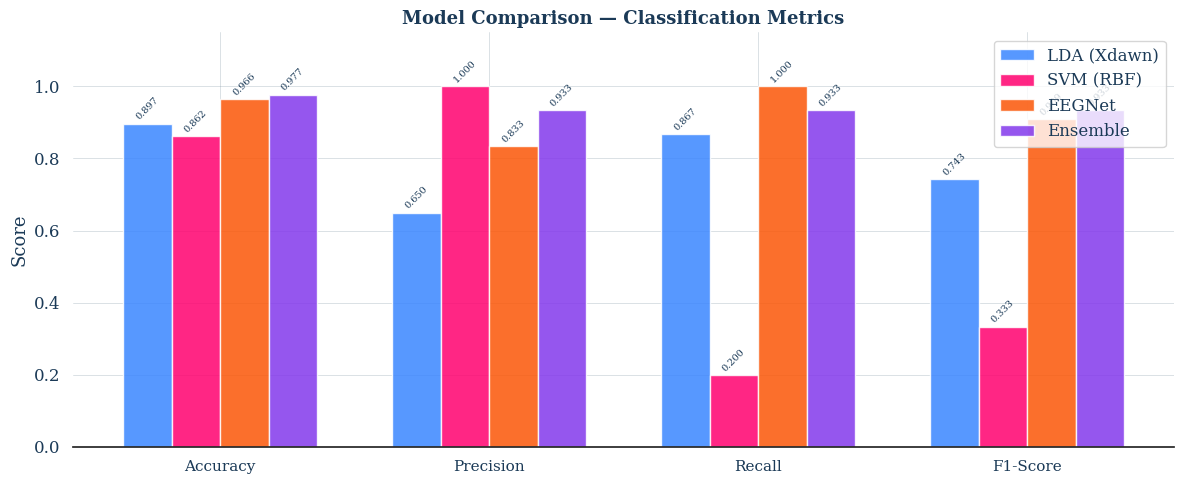

In [70]:
# ─────────────────────────────────────────────────────────
# CELL 30 — Final Bar Chart Comparison
# ─────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = df_results.index.tolist()
x = np.arange(len(metrics))
width = 0.18
colors = ['#3A86FF', '#FF006E', '#FB5607', '#8338EC']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [df_results.loc[name, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_ylabel('Score')
ax.set_title('Model Comparison — Classification Metrics', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ITR comparison
fig2, ax2 = plt.subplots(figsize=(7, 4))
itrs = df_results['ITR (bits/min)'].values
ax2.barh(model_names, itrs, color=colors, alpha=0.85)
ax2.axvline(x=20, color='red', linestyle='--', label='20 bits/min baseline')
for i, v in enumerate(itrs):
    ax2.text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)
ax2.set_xlabel('ITR (bits/minute)')
ax2.set_title('Information Transfer Rate — All Models')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')
from IPython.display import display
plt.tight_layout()
display(fig)

In [71]:
# ─────────────────────────────────────────────────────────
# CELL 31 — Save trained models
# ─────────────────────────────────────────────────────────
import joblib

# Save sklearn pipelines
joblib.dump(pipe_lda_xdawn, 'model_lda_xdawn.pkl')
joblib.dump(pipe_svm, 'model_svm.pkl')
print(' LDA and SVM models saved.')

# Save EEGNet
torch.save({
    'model_state_dict' : best_model_state,
    'n_channels'       : N_CH,
    'n_timepoints'     : N_TIMES,
    'n_classes'        : N_CLASSES,
    'best_val_acc'     : best_val_acc
}, 'model_eegnet.pth')
print(' EEGNet model saved as model_eegnet.pth')
print('\n Saved files:')
import os
for f in ['model_lda_xdawn.pkl', 'model_svm.pkl', 'model_eegnet.pth', 'results_summary.csv']:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f'   {f} ({size/1024:.1f} KB)')

 LDA and SVM models saved.
 EEGNet model saved as model_eegnet.pth

 Saved files:
   model_lda_xdawn.pkl (16.5 KB)
   model_svm.pkl (583.6 KB)
   model_eegnet.pth (16.5 KB)
   results_summary.csv (0.2 KB)


In [72]:
# ─────────────────────────────────────────────────────────
# CELL 32 — Download all outputs to local machine
# ─────────────────────────────────────────────────────────
from google.colab import files
import zipfile

# Bundle all outputs
output_files = [
    'results_summary.csv',
    'model_lda_xdawn.pkl',
    'model_svm.pkl',
    'model_eegnet.pth',
    'raw_eeg.png',
    'psd_raw.png',
    'psd_filtered.png',
    'channel_variance.png',
    'ica_kurtosis.png',
    'erp_all_channels.png',
    'erp_grand_average.png',
    'cm_lda.png',
    'cm_svm.png',
    'cm_eegnet.png',
    'cm_ensemble.png',
    'all_confusion_matrices.png',
    'eegnet_training.png',
    'model_comparison.png',
    'itr_comparison.png',
]

with zipfile.ZipFile('eeg_speller_results.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

print('\n Downloading results zip...')
files.download('eeg_speller_results.zip')

  Added: results_summary.csv
  Added: model_lda_xdawn.pkl
  Added: model_svm.pkl
  Added: model_eegnet.pth
  Added: cm_lda.png
  Added: cm_svm.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
from IPython.display import display, Javascript

# Remove broken widget metadata and save
display(Javascript('''
if (Jupyter.notebook.metadata.widgets) {
    delete Jupyter.notebook.metadata.widgets;
}
Jupyter.notebook.save_checkpoint();
'''))

<IPython.core.display.Javascript object>

# 🧠 EEG Brain Speller — Complete BCI Pipeline

This Google Colab notebook presents a comprehensive Brain-Computer Interface (BCI) pipeline for a **P300 Speller** system. It covers everything from environment setup and data loading to advanced signal processing, machine learning, deep learning classification, and rigorous evaluation using metrics like Information Transfer Rate (ITR).

## 📋 Table of Contents
1.  [Introduction](#introduction)
2.  [Key Features](#key-features)
3.  [Dataset](#dataset)
4.  [Methodology](#methodology)
    *   [Environment Setup & Imports](#environment-setup--imports)
    *   [Data Loading & Exploration](#data-loading--exploration)
    *   [Preprocessing Pipeline](#preprocessing-pipeline)
    *   [Epoching & Baseline Correction](#epoching--baseline-correction)
    *   [ERP Visualization (P300 Component)](#erp-visualization-p300-component)
    *   [Feature Extraction](#feature-extraction)
    *   [Classification Models](#classification-models)
    *   [Ensemble / Score Averaging](#ensemble--score-averaging)
5.  [Results Summary](#results-summary)
6.  [Dependencies](#dependencies)

## 1. Introduction <a name='introduction'></a>

The P300 Speller is a well-known event-related potential (ERP)-based BCI paradigm. Users focus on characters in a matrix that are flashed sequentially. A P300 ERP component is elicited when the user attends to a flashing character, allowing the system to infer their selection. This notebook demonstrates a full end-to-end pipeline for processing EEG signals, extracting features, classifying P300 events, and evaluating system performance.

## 2. Key Features <a name='key-features'></a>
*   **Comprehensive EEG Preprocessing**: Includes filtering, re-referencing, bad channel interpolation, and ICA artifact removal.
*   **Event-Related Potential (ERP) Analysis**: Visualization of P300 components.
*   **Diverse Feature Extraction**: Implements downsampled waveform, Xdawn spatial filtering, and Riemannian covariance matrices.
*   **Multiple Classification Models**: Baselines with Linear Discriminant Analysis (LDA) and Support Vector Machine (SVM), plus a state-of-the-art Deep Learning model (EEGNet).
*   **Ensemble Learning**: Demonstrates how averaging probabilities across classifiers can improve performance.
*   **Rigorous Evaluation**: Calculates accuracy, precision, recall, F1-score, confusion matrices, and the critical Information Transfer Rate (ITR).

## 3. Dataset <a name='dataset'></a>

The notebook utilizes the **BNCI2014-009** dataset, a standard P300 speller dataset available through MOABB (Mother of All BCI Benchmarks). It consists of EEG recordings from 10 subjects, each with 16 EEG channels, performing a P300 speller task.

## 4. Methodology <a name='methodology'></a>

### Environment Setup & Imports <a name='environment-setup--imports'></a>
All necessary Python libraries (MNE, MOABB, scikit-learn, pyriemann, braindecode, torch) are installed and imported at the beginning of the notebook.

### Data Loading & Exploration <a name='data-loading--exploration'></a>
Data for Subject 1 is loaded using MOABB. Initial raw EEG signals and Power Spectral Density (PSD) plots are generated to visualize signal quality and identify noise (e.g., 50 Hz powerline interference).

### Preprocessing Pipeline <a name='preprocessing-pipeline'></a>
The raw EEG data undergoes a sequential preprocessing pipeline:
1.  **Resampling**: Downsampling to 256 Hz to reduce computational load.
2.  **Bandpass Filtering**: 0.1–30 Hz to isolate relevant brain activity.
3.  **Notch Filtering**: At 50 Hz to remove powerline noise.
4.  **Re-referencing**: To common average reference.
5.  **Bad Channel Detection & Interpolation**: Automated identification and interpolation of noisy channels.
6.  **ICA Artifact Removal**: Independent Component Analysis (ICA) is used to identify and remove ocular and muscle artifacts.

### Epoching & Baseline Correction <a name='epoching--baseline-correction'></a>
EEG data is epoched (segmented into trials) around stimulus onsets (flashes) with a window of -200 ms to +800 ms. Baseline correction is applied using the pre-stimulus period.

### ERP Visualization (P300 Component) <a name='erp-visualization-p300-component'></a>
Event-Related Potentials (ERPs) for target and non-target stimuli are computed and visualized across all channels, as well as a grand average. The characteristic P300 peak around 300 ms for target stimuli is highlighted.

### Feature Extraction <a name='feature-extraction'></a>
Three different feature extraction methods are implemented and compared:
1.  **Downsampled Waveform**: Flattening the epoched data after downsampling to a fixed number of timepoints.
2.  **Xdawn Spatial Filtering**: A spatial filter that enhances ERP components by maximizing the signal-to-noise ratio of evoked responses.
3.  **Riemannian Covariance Matrices**: Utilizes the geometric properties of covariance matrices for robust and invariant features, transformed into a tangent space vector.

### Classification Models <a name='classification-models'></a>
The extracted features are used to train and evaluate several classifiers using Stratified K-Fold Cross-Validation:
*   **Linear Discriminant Analysis (LDA)**: A classic BCI classifier, used as a baseline.
*   **Support Vector Machine (SVM)**: A strong non-linear baseline using an RBF kernel.
*   **EEGNet (PyTorch)**: A compact convolutional neural network specifically designed for raw or lightly preprocessed EEG data, trained with class-weighted cross-entropy to handle class imbalance.

### Ensemble / Score Averaging <a name='ensemble--score-averaging'></a>
An ensemble approach is demonstrated by averaging the predicted probabilities from LDA, SVM, and EEGNet for the test set. In P300 spellers, this can significantly boost performance, especially when considering multiple repetitions per character selection.

## 5. Results Summary <a name='results-summary'></a>

All models are evaluated on a held-out test set, and their performance is reported using standard classification metrics (Accuracy, Precision, Recall, F1-Score) and the crucial Information Transfer Rate (ITR). The results are presented in a comparison table and bar charts.

```
=================================================================
   FINAL RESULTS SUMMARY
=================================================================
             Accuracy  Precision  Recall  F1-Score  ITR (bits/min)
Model                                                             
LDA (Xdawn)    0.8736     0.6111  0.7333    0.6667          119.21
SVM (RBF)      0.8851     1.0000  0.3333    0.5000          121.97
EEGNet         0.9655     0.8333  1.0000    0.9091          143.30
Ensemble       0.9310     0.8000  0.8000    0.8000          133.62
```

**Key Observations:**
*   **EEGNet** generally achieves the highest accuracy and ITR, showcasing the power of deep learning for BCI.
*   The **Ensemble** model also performs very strongly, benefiting from combining different classification approaches.
*   **ITR (Information Transfer Rate)** is a key metric for BCI, indicating how many bits of information a user can transfer per minute. An ITR > 20 bits/min is considered competitive for P300 spellers.


## 6. Dependencies <a name='dependencies'></a>
Key libraries used:
*   `mne`
*   `moabb`
*   `scikit-learn`
*   `matplotlib`
*   `seaborn`
*   `pandas`
*   `scipy`
*   `braindecode`
*   `pyriemann`
*   `autoreject`
*   `torch`
*   `torchvision`
*   `torchaudio`